In [198]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

## Normaliserer data


In [199]:
df0109_1 = pd.read_csv('../data/split/no_plug/0109-1.csv')
df2106_3 = pd.read_csv('../data/split/no_plug/2106-3.csv')
df2906_1 = pd.read_csv('../data/split/no_plug/2906-1.csv')
df3006_1 = pd.read_csv('../data/split/no_plug/3006-1.csv')
df3006_2 = pd.read_csv('../data/split/no_plug/3006-2.csv')
df0404 = pd.read_csv('../data/split/no_plug/0404.csv')
df0712 = pd.read_csv('../data/split/no_plug/0712.csv')

df1803 = pd.read_csv('../data/split/partial_plug/1803.csv')
df1103 = pd.read_csv('../data/split/partial_plug/1103.csv')
df2503 = pd.read_csv('../data/split/partial_plug/2503.csv')

df0709 = pd.read_csv('../data/split/plug/0709.csv')
df2106_1 = pd.read_csv('../data/split/plug/2106-1.csv')
df2106_2 = pd.read_csv('../data/split/plug/2106-2.csv')
df2108_1 = pd.read_csv('../data/split/plug/2108-1.csv')
df2108_2 = pd.read_csv('../data/split/plug/2108-2.csv')
df2401_1 = pd.read_csv('../data/split/plug/2401-1.csv')
df2401_2 = pd.read_csv('../data/split/plug/2401-2.csv')
df2906_2 = pd.read_csv('../data/split/plug/2906-2.csv')
df2906_3 = pd.read_csv('../data/split/plug/2906-3.csv')
df2906_4 = pd.read_csv('../data/split/plug/2906-4.csv')
df3006_3 = pd.read_csv('../data/split/plug/3006-3.csv')
df0612_1 = pd.read_csv('../data/split/plug/0612-1.csv')
df0612_2 = pd.read_csv('../data/split/plug/0612-2.csv')
df0612_3 = pd.read_csv('../data/split/plug/0612-3.csv')
df0707_1 = pd.read_csv('../data/split/plug/0707-1.csv')
df0707_2 = pd.read_csv('../data/split/plug/0707-2.csv')
df0707_3 = pd.read_csv('../data/split/plug/0707-3.csv')
df0707_4 = pd.read_csv('../data/split/plug/0707-4.csv')
df1112 = pd.read_csv('../data/split/plug/1112.csv')
df1310_1 = pd.read_csv('../data/split/plug/1310-1.csv')
df1310_2 = pd.read_csv('../data/split/plug/1310-2.csv')
df1310_3 = pd.read_csv('../data/split/plug/1310-3.csv')
df1407_1 = pd.read_csv('../data/split/plug/1407-1.csv')
df1407_2 = pd.read_csv('../data/split/plug/1407-2.csv')
df1407_3 = pd.read_csv('../data/split/plug/1407-3.csv')
df1407_4 = pd.read_csv('../data/split/plug/1407-4.csv')
df1503 = pd.read_csv('../data/split/plug/1503.csv')
df1811 = pd.read_csv('../data/split/plug/1811.csv')
df2701 = pd.read_csv('../data/split/plug/2701.csv')

In [200]:
dfs = [df0109_1, df1803, df2106_3, df2906_1, df3006_1, df3006_2, df0404, df0712, df1103, df2503, df0709, df2106_1, df2106_2, df2108_1, df2108_2, df2401_1, df2401_2, df2906_2, df2906_3, df2906_4, df3006_3, df0612_1, df0612_2, df0612_3, df0707_1, df0707_2, df0707_3, df0707_4, df1112, df1310_1, df1310_2, df1310_3, df1407_1, df1407_2, df1407_3, df1407_4, df1503, df1811, df2701]

dfnames = ['0109-1', '1803', '2106-3', '2906-1', '3006-1', '3006-2', '0404', '0712', '1103', '2503', '0709', '2106-1', '2106-2', '2108-1', '2108-2', '2401-1', '2401-2', '2906-2', '2906-3', '2906-4', '3006-3', '0612-1', '0612-2', '0612-3', '0707-1', '0707-2', '0707-3', '0707-4', '1112', '1310-1', '1310-2', '1310-3', '1407-1', '1407-2', '1407-3', '1407-4', '1503', '1811', '2701']

Tar en tilfeldig df og ser om kolonnene matcher med de andre, de som ikke matcher, legges til i en liste

In [201]:
not_matching = []
not_matching_names = []
for i in range (len(dfs)):
    if(df3006_2.columns.equals(dfs[i].columns)):
        continue
    else:
        not_matching.append(dfs[i])
        not_matching_names.append(dfnames[i])

Sjekker om de mismatchende dfs matcher hverandre

In [202]:
for df in not_matching:
    print(df.columns == not_matching[0].columns)

[ True  True  True  True  True  True  True  True  True  True  True  True]
[ True  True  True  True  True  True  True  True  True  True  True  True]
[ True  True  True  True  True  True  True  True  True  True  True  True]
[ True  True  True  True  True  True  True  True  True  True  True  True]
[ True  True  True  True  True  True  True  True  True  True  True  True]


In [203]:
print(not_matching_names)

['0109-1', '0712', '2108-1', '2108-2', '1112']


Mapper navn på kolonner slik at de matcher hverandre

In [204]:
mapping = {
        'Pressure before pump (Arith. Mean)': 'Pump outlet pressure (Mean)',
        'Pressure after pump (Arith. Mean)': 'TS outlet pressure (Mean)',
        'Differential pressure (Arith. Mean)': 'Differential pressure (Mean)',
        'Flow rate (Arith. Mean)': 'Flow rate (Mean)',
        'Tank temperature (Arith. Mean)': 'Tank temperature (Mean)',
        'Temperature TS inlet (Arith. Mean)': 'Temperature TS inlet (Mean)',
        'Temperature TS outlet (Arith. Mean)': 'Temperature TS outlet (Mean)',
        'Bypass temperature (Arith. Mean)': 'Bypass temperature (Mean)'
    }
df0109_1 = df0109_1.rename(columns=mapping)
df2108_1 = df2108_1.rename(columns=mapping)
df2108_2 = df2108_2.rename(columns=mapping)
df1112 = df1112.rename(columns=mapping)
df0712 = df0712.rename(columns=mapping)

Legger til en diff pressure kolonne i hver df

In [205]:
dfs = [df0109_1, df1803, df2106_3, df2906_1, df3006_1, df3006_2, df0404, df0712, df1103, 
       df2503, df0709, df2106_1, df2106_2, df2108_1, df2108_2, df2401_1, df2401_2, df2906_2, 
       df2906_3, df2906_4, df3006_3, df0612_1, df0612_2, df0612_3, df0707_1, df0707_2, df0707_3, 
       df0707_4, df1112, df1310_1, df1310_2, df1310_3, df1407_1, df1407_2, df1407_3, df1407_4, df1503, df1811, df2701]

for df in dfs:
    if 'TS inlet pressure (Mean)' in df.columns:
        df['Differential pressure (Mean)'] = df['TS inlet pressure (Mean)'] - df['TS outlet pressure (Mean)']
        df['Pump to inlet DP'] = df['Pump outlet pressure (Mean)'] - df['TS inlet pressure (Mean)']
        df['Total system DP'] = df['Pump outlet pressure (Mean)'] - df['TS outlet pressure (Mean)']
    else:
        df['TS inlet pressure (Mean)'] = df['TS outlet pressure (Mean)'] + df['Differential pressure (Mean)']
        df['Pump to inlet DP'] = df['Pump outlet pressure (Mean)'] - df['TS inlet pressure (Mean)']
        df['Total system DP'] = df['Pump outlet pressure (Mean)'] - df['TS outlet pressure (Mean)']

Fra unsupervised labeling har jeg måttet droppet noen dfs, dette er de resterende dfs jeg fortsatt kan bruke:

In [206]:
plug_dfs = [df0709, df2106_2, df2108_1, df2108_2, df2906_2, df2906_3, 
            df2906_4, df3006_3, df0612_2, df0612_3, df0707_1, df0707_2, df0707_4, df1112, 
            df1310_2, df1310_3, df1407_1, df1407_2, df1407_3, df1407_4, df1503, df1811, df2701]
#1003, bigplug
plug_names = [
            '0709', '2106-2', '2108-1', '2108-2', '2906-2', '2906-3',
            '2906-4', '3006-3', '0612-2', '0612-3', '0707-1', '0707-2', '0707-4', '1112', 
            '1310-2', '1310-3', '1407-1', '1407-2', '1407-3', '1407-4', '1503', '1811', '2701', '1003']

partial_plug_dfs = [df1803, df1103, df2503]
partial_plug_names = ['1803', '1103', '2503']

no_plug_dfs = [df2906_1, df3006_1, df3006_2, df0404, df0712]
# 1703, bignoplug
no_plug_names = ['2906-1', '3006-1', '3006-2', '0404', '0712', '1703']

Passer på at alle kolonnene er i samme rekkefølge i alle dfs

In [207]:
master_column_order = [
    'Time',
    'Temperature TS inlet (Mean)',
    'Temperature TS outlet (Mean)',
    'Tank temperature (Mean)',
    'Bypass temperature (Mean)',
    'Pump outlet pressure (Mean)',
    'TS inlet pressure (Mean)',
    'TS outlet pressure (Mean)',
    'Differential pressure (Mean)',
    'Pump to inlet DP',
    'Total system DP',
    'Flow rate (Mean)',
    'reading_interval_s',
    'elapsed_runtime_s',
    'elapsed_runtime_m'
]

In [208]:
standardized_plugs = []
standardized_no_plugs = []
standardized_partial_plugs = []
for df in plug_dfs:
    df_reordered = df[master_column_order].copy()
    df_reordered = df_reordered.sort_values('elapsed_runtime_s').reset_index(drop=True)
    standardized_plugs.append(df_reordered)

for df in partial_plug_dfs:
    df_reordered = df[master_column_order].copy()
    df_reordered = df_reordered.sort_values('elapsed_runtime_s').reset_index(drop=True)
    standardized_partial_plugs.append(df_reordered)

for df in no_plug_dfs:
    df_reordered = df[master_column_order].copy()
    df_reordered = df_reordered.sort_values('elapsed_runtime_s').reset_index(drop=True)
    standardized_no_plugs.append(df_reordered)

Sanity check at alle kolonnene er like i alle dfs

In [209]:
for df in standardized_no_plugs:
    if(standardized_no_plugs[0].columns != df.columns).any():
        print('Mismatch!')
for df in standardized_plugs:
    if(standardized_plugs[0].columns != df.columns).any():
        print('Mismatch!')
for df in standardized_partial_plugs:
    if(standardized_partial_plugs[0].columns != df.columns).any():
        print('Mismatch!')

## Algoritme for å gi labels til runs

In [210]:
def label_three_tier_runs(df1, t1, t2, smooth_window, min_b, max_b, percentage, persist, base):
    df = df1.copy()
    
    baseline_rows = min(max(min_b, int(len(df) * percentage)), max_b)
    
    base_dp_val = df['Total system DP'].iloc[:baseline_rows].median()
    df['Relative_DP'] = df['Total system DP'] / (base_dp_val + 1e-6)
    
    df['Pressure_Ratio'] = (df['TS inlet pressure (Mean)'] - df['TS outlet pressure (Mean)']) / \
                           (df['Pump outlet pressure (Mean)'] - df['TS inlet pressure (Mean)'] + 1e-6)
    
    base_ratio_val = df['Pressure_Ratio'].iloc[:baseline_rows].median()
    
    df['Relative_Ratio_Dev'] = (df['Pressure_Ratio'] / (base_ratio_val + 1e-6) - 1).abs()
    
    smoothed = df[base].rolling(window=smooth_window, min_periods=1).mean()

    is_above_t1 = (smoothed > t1).astype(int)
    roll_sum_t1 = is_above_t1.rolling(window=persist, min_periods=1).sum()
    triggers_t1 = (roll_sum_t1[baseline_rows:] >= persist)
    
    is_above_t2 = (smoothed > t2).astype(int)
    roll_sum_t2 = is_above_t2.rolling(window=persist, min_periods=1).sum()
    triggers_t2 = (roll_sum_t2[baseline_rows:] >= persist)

    df['Plug_Label'] = 0
    
    if triggers_t1.any():
        t1_idx = triggers_t1.idxmax()
        df.loc[t1_idx:, 'Plug_Label'] = 1
        
    if triggers_t2.any():
        t2_idx = triggers_t2.idxmax()
        df.loc[t2_idx:, 'Plug_Label'] = 2
        
    return df


## Leter etter beste verdier til algoritmen via grid search

In [ ]:
window_options = [3, 4, 5, 6, 7, 10] 
min_options = [10, 15, 20, 30]
max_options = [75, 100, 125, 150, 200, 600]
percentage_baseline = [0.05, 0.1, 0.15]
persistence_options = [1, 2, 3, 4, 5, 6, 7]
base_options = ['Relative_DP', 'Relative_Ratio_Dev']

optimization_results = []

for b in base_options:
    if b == 'Relative_DP':
        t1_options = [1.02, 1.03, 1.04, 1.05, 1.10] 
        t2_options = [1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.1, 1.15]
    else:
        t1_options = [0.01, 0.02, 0.03, 0.04, 0.05, 0.08, 0.10]
        t2_options = [0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.10, 0.15, 0.20, 0.30] 
    for t1 in t1_options:
        for t2 in t2_options:
            if t2 > t1:

                for w in window_options:
                    for min_b in min_options:
                        for max_b in max_options:
                            for perc in percentage_baseline:
                                for persist in persistence_options:

                                    clean_failures = 0 
                                    clean_partial = 0
                                    clean_correct = 0
                                    partial_no = 0
                                    partial_correct = 0 
                                    partial_full = 0
                                    full_wrong = 0
                                    full_partial = 0
                                    full_correct = 0  
                                    
                                    for df in no_plug_dfs:
                                        res = label_three_tier_runs(df, t1, t2, w, min_b, max_b, perc, persist, b)
                                        if res['Plug_Label'].max() == 2:
                                            clean_failures += 1
                                        if res['Plug_Label'].max() == 1:
                                            clean_partial += 1
                                        if res['Plug_Label'].max() == 0:
                                            clean_correct += 1
                                            
                                    for df in partial_plug_dfs:
                                        res = label_three_tier_runs(df, t1, t2, w, min_b, max_b, perc, persist, b)
                                        if res['Plug_Label'].max() == 2:
                                            partial_full += 1
                                        if res['Plug_Label'].max() == 1:
                                            partial_correct += 1
                                        if res['Plug_Label'].max() == 0:
                                            partial_no += 1
                                            
                                    for df in plug_dfs:
                                        res = label_three_tier_runs(df, t1, t2, w, min_b, max_b, perc, persist, b)
                                        if res['Plug_Label'].max() == 2:
                                            full_correct += 1
                                        if res['Plug_Label'].max() == 1:
                                            full_partial += 1
                                        if res['Plug_Label'].max() == 0:
                                            full_wrong += 1    
                                    
                                    optimization_results.append({
                                        'T1': t1, 'T2': t2, 'Win': w,
                                        'Clean_Fail': clean_failures,
                                        'Clean_partial': clean_partial,
                                        'clean_correct': clean_correct,
                                        'Partial_correct': partial_correct,
                                        'Partial_full': partial_full,
                                        'Partial_no': partial_no,
                                        'Full_Found': full_correct,
                                        'Full_partial': full_partial,
                                        'Full_wrong': full_wrong,
                                        'Base': b, 'Persist': persist,
                                        'percentage_baseline': perc,
                                        'min_options': min_b,
                                        'max_options': max_b
                                    })

In [ ]:
#opt_df.to_csv('../data/optimizationResults/results0804.csv', index=False)

In [80]:
opt_df = pd.read_csv('../data/optimizationResults/results0804.csv')
#opt_df = opt_df[opt_df['Base'] != 'Relative_DP']
sorted_results = opt_df.sort_values(
    by=['clean_correct','Full_wrong'], 
    ascending=[False, True]
)
print(sorted_results.head(10))

         T1    T2  Win  Clean_Fail  Clean_partial  clean_correct  \
46877  1.04  1.05    6           1              0              4   
46898  1.04  1.05    6           1              0              4   
46919  1.04  1.05    6           1              0              4   
46939  1.04  1.05    6           1              0              4   
46940  1.04  1.05    6           1              0              4   
46953  1.04  1.05    6           1              0              4   
46960  1.04  1.05    6           1              0              4   
46961  1.04  1.05    6           1              0              4   
46974  1.04  1.05    6           1              0              4   
46981  1.04  1.05    6           1              0              4   

       Partial_correct  Partial_full  Partial_no  Full_Found  Full_partial  \
46877                0             1           2          12             3   
46898                0             1           2          12             3   
46919            

In [ ]:
window_options = [2, 3, 4, 5, 6, 7, 10, 15, 20] 
min_options = [30]
max_options = [300]
percentage_baseline = [0.05, 0.1, 0.15]
persistence_options = [5, 6, 7, 8, 9, 10, 14]
base_options = ['Relative_Ratio_Dev']

optimization_results = []

for b in base_options:
    t1_options = [0.20, 0.22, 0.24, 0.26, 0.30]
    t2_options = [0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8] 
    for t1 in t1_options:
        for t2 in t2_options:
            if t2 > t1:

                for w in window_options:
                    for min_b in min_options:
                        for max_b in max_options:
                            for perc in percentage_baseline:
                                for persist in persistence_options:
                                    
                                    clean_failures = 0 
                                    clean_partial = 0
                                    clean_correct = 0
                                    partial_no = 0
                                    partial_correct = 0 
                                    partial_full = 0
                                    full_wrong = 0
                                    full_partial = 0
                                    full_correct = 0  
                                    
                                    for df in no_plug_dfs:
                                        res = label_three_tier_runs(df, t1, t2, w, min_b, max_b, perc, persist, b)
                                        if res['Plug_Label'].max() == 2:
                                            clean_failures += 1
                                        if res['Plug_Label'].max() == 1:
                                            clean_partial += 1
                                        if res['Plug_Label'].max() == 0:
                                            clean_correct += 1
                                            
                                    for df in partial_plug_dfs:
                                        res = label_three_tier_runs(df, t1, t2, w, min_b, max_b, perc, persist, b)
                                        if res['Plug_Label'].max() == 2:
                                            partial_full += 1
                                        if res['Plug_Label'].max() == 1:
                                            partial_correct += 1
                                        if res['Plug_Label'].max() == 0:
                                            partial_no += 1
                                            
                                    for df in plug_dfs:
                                        res = label_three_tier_runs(df, t1, t2, w, min_b, max_b, perc, persist, b)
                                        if res['Plug_Label'].max() == 2:
                                            full_correct += 1
                                        if res['Plug_Label'].max() == 1:
                                            full_partial += 1
                                        if res['Plug_Label'].max() == 0:
                                            full_wrong += 1    
                                    
                                    optimization_results.append({
                                        'T1': t1, 'T2': t2, 'Win': w,
                                        'Clean_Fail': clean_failures,
                                        'Clean_partial': clean_partial,
                                        'clean_correct': clean_correct,
                                        'Partial_correct': partial_correct,
                                        'Partial_full': partial_full,
                                        'Partial_no': partial_no,
                                        'Full_Found': full_correct,
                                        'Full_partial': full_partial,
                                        'Full_wrong': full_wrong,
                                        'Base': b, 'Persist': persist,
                                        'percentage_baseline': perc,
                                        'min_options': min_b,
                                        'max_options': max_b

                                    })


In [ ]:

opt_df = pd.DataFrame(optimization_results)
sorted_results = opt_df.sort_values(
    by=['clean_correct', 'Full_wrong', 'Clean_Fail', 'Full_Found'], 
    ascending=[False, True, True, False]
)

print(sorted_results.head(10))

        T1    T2  Win  Clean_Fail  Clean_partial  clean_correct  \
1071  0.22  0.75    5           1              2              2   
1239  0.22  0.76    5           1              2              2   
1407  0.22  0.77    5           1              2              2   
1025  0.22  0.75    2           1              2              2   
1113  0.22  0.75    7           1              2              2   
1175  0.22  0.75   15           1              2              2   
1214  0.22  0.76    3           1              2              2   
1281  0.22  0.76    7           1              2              2   
1512  0.22  0.78    2           1              2              2   
1542  0.22  0.78    3           1              2              2   

      Partial_correct  Partial_full  Partial_no  Full_Found  Full_partial  \
1071                2             0           1          12            11   
1239                2             0           1          12            11   
1407                2          

In [ ]:
window_options = [10, 15, 20, 25, 30]
min_options = [30]
max_options = [300]
percentage_baseline = [0.05, 0.1, 0.15]
persistence_options = [15, 20, 25, 30, 35, 40, 45, 60]
base_options = ['Relative_Ratio_Dev']

optimization_results = []

for b in base_options:
    t1_options = [0.18, 0.19, 0.20, 0.22, 0.24] 
    t2_options = [ 0.75, 0.76, 0.77, 0.78, 0.80, 0.82] 
    for t1 in t1_options:
        for t2 in t2_options:
            if t2 > t1:

                for w in window_options:
                    for min_b in min_options:
                        for max_b in max_options:
                            for perc in percentage_baseline:
                                for persist in persistence_options:
                                    
                                    clean_failures = 0 
                                    clean_partial = 0
                                    clean_correct = 0
                                    partial_no = 0
                                    partial_correct = 0 
                                    partial_full = 0
                                    full_wrong = 0
                                    full_partial = 0
                                    full_correct = 0  
                                    
                                    for df in no_plug_dfs:
                                        res = label_three_tier_runs(df, t1, t2, w, min_b, max_b, perc, persist, b)
                                        if res['Plug_Label'].max() == 2:
                                            clean_failures += 1
                                        if res['Plug_Label'].max() == 1:
                                            clean_partial += 1
                                        if res['Plug_Label'].max() == 0:
                                            clean_correct += 1
                                            
                                    for df in partial_plug_dfs:
                                        res = label_three_tier_runs(df, t1, t2, w, min_b, max_b, perc, persist, b)
                                        if res['Plug_Label'].max() == 2:
                                            partial_full += 1
                                        if res['Plug_Label'].max() == 1:
                                            partial_correct += 1
                                        if res['Plug_Label'].max() == 0:
                                            partial_no += 1

                                    for df in plug_dfs:
                                        res = label_three_tier_runs(df, t1, t2, w, min_b, max_b, perc, persist, b)
                                        if res['Plug_Label'].max() == 2:
                                            full_correct += 1
                                        if res['Plug_Label'].max() == 1:
                                            full_partial += 1
                                        if res['Plug_Label'].max() == 0:
                                            full_wrong += 1    
                                    
                                    optimization_results.append({
                                        'T1': t1, 'T2': t2, 'Win': w,
                                        'Clean_Fail': clean_failures,
                                        'Clean_partial': clean_partial,
                                        'clean_correct': clean_correct,
                                        'Partial_correct': partial_correct,
                                        'Partial_full': partial_full,
                                        'Partial_no': partial_no,
                                        'Full_Found': full_correct,
                                        'Full_partial': full_partial,
                                        'Full_wrong': full_wrong,
                                        'Base': b, 'Persist': persist,
                                        'percentage_baseline': perc,
                                        'min_options': min_b,
                                        'max_options': max_b

                                    })


In [ ]:
opt_df = pd.DataFrame(optimization_results)
sorted_results = opt_df.sort_values(
    by=['Clean_Fail', 'Full_wrong','clean_correct', 'Full_Found'], 
    ascending=[True, True, False, False]
)

print(sorted_results.head(10))

        T1    T2  Win  Clean_Fail  Clean_partial  clean_correct  \
1848  0.19  0.78   20           0              4              1   
1849  0.19  0.78   20           0              4              1   
1872  0.19  0.78   25           0              4              1   
1873  0.19  0.78   25           0              4              1   
1968  0.19  0.80   20           0              4              1   
1969  0.19  0.80   20           0              4              1   
1992  0.19  0.80   25           0              4              1   
1993  0.19  0.80   25           0              4              1   
2016  0.19  0.80   30           0              4              1   
2064  0.19  0.82   15           0              4              1   

      Partial_correct  Partial_full  Partial_no  Full_Found  Full_partial  \
1848                2             0           1          10            13   
1849                2             0           1          10            13   
1872                2          

In [ ]:
optimization_results = []
window_options = [5, 8, 10, 12, 15] 

min_options = [30]
max_options = [300]

percentage_baseline = [0.02, 0.05, 0.08] 

persistence_options = [5, 10, 15, 20, 25]

base_options = ['Relative_Ratio_Dev']

for b in base_options:
    t1_options = [0.18, 0.19, 0.20] 
    
    t2_options = [0.70, 0.72, 0.75, 0.78, 0.80]
    for t1 in t1_options:
        for t2 in t2_options:
            if t2 > t1:

                for w in window_options:
                    for min_b in min_options:
                        for max_b in max_options:
                            for perc in percentage_baseline:
                                for persist in persistence_options:
                                    
                                    clean_failures = 0 
                                    clean_partial = 0
                                    clean_correct = 0
                                    partial_no = 0
                                    partial_correct = 0 
                                    partial_full = 0
                                    full_wrong = 0
                                    full_partial = 0
                                    full_correct = 0  
                                    
                                    for df in no_plug_dfs:
                                        res = label_three_tier_runs(df, t1, t2, w, min_b, max_b, perc, persist, b)
                                        if res['Plug_Label'].max() == 2:
                                            clean_failures += 1
                                        if res['Plug_Label'].max() == 1:
                                            clean_partial += 1
                                        if res['Plug_Label'].max() == 0:
                                            clean_correct += 1
                                            
                                    for df in partial_plug_dfs:
                                        res = label_three_tier_runs(df, t1, t2, w, min_b, max_b, perc, persist, b)
                                        if res['Plug_Label'].max() == 2:
                                            partial_full += 1
                                        if res['Plug_Label'].max() == 1:
                                            partial_correct += 1
                                        if res['Plug_Label'].max() == 0:
                                            partial_no += 1
                                            
                                    for df in plug_dfs:
                                        res = label_three_tier_runs(df, t1, t2, w, min_b, max_b, perc, persist, b)
                                        if res['Plug_Label'].max() == 2:
                                            full_correct += 1
                                        if res['Plug_Label'].max() == 1:
                                            full_partial += 1
                                        if res['Plug_Label'].max() == 0:
                                            full_wrong += 1    
                                    
                                    optimization_results.append({
                                        'T1': t1, 'T2': t2, 'Win': w,
                                        'Clean_Fail': clean_failures,
                                        'Clean_partial': clean_partial,
                                        'clean_correct': clean_correct,
                                        'Partial_correct': partial_correct,
                                        'Partial_full': partial_full,
                                        'Partial_no': partial_no,
                                        'Full_Found': full_correct,
                                        'Full_partial': full_partial,
                                        'Full_wrong': full_wrong,
                                        'Base': b, 'Persist': persist,
                                        'percentage_baseline': perc,
                                        'min_options': min_b,
                                        'max_options': max_b

                                    })


In [ ]:
opt_df = pd.DataFrame(optimization_results)
sorted_results = opt_df.sort_values(
    by=['Full_wrong', 'Clean_Fail', 'clean_correct', 'Full_Found', 'percentage_baseline'], 
    ascending=[True, True, False, False, False]
)

print(sorted_results.head(10))

       T1    T2  Win  Clean_Fail  Clean_partial  clean_correct  \
391  0.19  0.70    8           0              4              1   
406  0.19  0.70   10           0              4              1   
421  0.19  0.70   12           0              4              1   
436  0.19  0.70   15           0              4              1   
765  0.20  0.70    8           0              4              1   
780  0.20  0.70   10           0              4              1   
781  0.20  0.70   10           0              4              1   
795  0.20  0.70   12           0              4              1   
810  0.20  0.70   15           0              4              1   
825  0.20  0.72    5           0              4              1   

     Partial_correct  Partial_full  Partial_no  Full_Found  Full_partial  \
391                2             0           1          12            11   
406                2             0           1          12            11   
421                2             0           

In [ ]:
optimization_results = []

window_options = [2, 5, 8, 10] 
min_options = [30]
max_options = [300]
percentage_baseline = [0.01, 0.015, 0.02] 
persistence_options = [2, 5, 8, 10]
base_options = ['Relative_Ratio_Dev']

for b in base_options:
    t1_options = [0.19, 0.20] 
    t2_options = [0.68, 0.70, 0.72]
    for t1 in t1_options:
        for t2 in t2_options:
            if t2 > t1:

                for w in window_options:
                    for min_b in min_options:
                        for max_b in max_options:
                            for perc in percentage_baseline:
                                for persist in persistence_options:
                                    
                                    clean_failures = 0 
                                    clean_partial = 0
                                    clean_correct = 0
                                    partial_no = 0
                                    partial_correct = 0 
                                    partial_full = 0
                                    full_wrong = 0
                                    full_partial = 0
                                    full_correct = 0  

                                    for df in no_plug_dfs:
                                        res = label_three_tier_runs(df, t1, t2, w, min_b, max_b, perc, persist, b)
                                        if res['Plug_Label'].max() == 2:
                                            clean_failures += 1
                                        if res['Plug_Label'].max() == 1:
                                            clean_partial += 1
                                        if res['Plug_Label'].max() == 0:
                                            clean_correct += 1
                                            
                                    for df in partial_plug_dfs:
                                        res = label_three_tier_runs(df, t1, t2, w, min_b, max_b, perc, persist, b)
                                        if res['Plug_Label'].max() == 2:
                                            partial_full += 1
                                        if res['Plug_Label'].max() == 1:
                                            partial_correct += 1
                                        if res['Plug_Label'].max() == 0:
                                            partial_no += 1

                                    for df in plug_dfs:
                                        res = label_three_tier_runs(df, t1, t2, w, min_b, max_b, perc, persist, b)
                                        if res['Plug_Label'].max() == 2:
                                            full_correct += 1
                                        if res['Plug_Label'].max() == 1:
                                            full_partial += 1
                                        if res['Plug_Label'].max() == 0:
                                            full_wrong += 1    
                                    
                                    optimization_results.append({
                                        'T1': t1, 'T2': t2, 'Win': w,
                                        'Clean_Fail': clean_failures,
                                        'Clean_partial': clean_partial,
                                        'clean_correct': clean_correct,
                                        'Partial_correct': partial_correct,
                                        'Partial_full': partial_full,
                                        'Partial_no': partial_no,
                                        'Full_Found': full_correct,
                                        'Full_partial': full_partial,
                                        'Full_wrong': full_wrong,
                                        'Base': b, 'Persist': persist,
                                        'percentage_baseline': perc,
                                        'min_options': min_b,
                                        'max_options': max_b

                                    })


In [ ]:

opt_df = pd.DataFrame(optimization_results)
sorted_results = opt_df.sort_values(
    by=['Full_wrong', 'Clean_Fail', 'clean_correct', 'Full_Found', 'percentage_baseline'], 
    ascending=[True, True, False, False, False]
)

print(sorted_results.head(10))

       T1    T2  Win  Clean_Fail  Clean_partial  clean_correct  \
177  0.20  0.68    8           0              4              1   
189  0.20  0.68   10           0              4              1   
236  0.20  0.70   10           0              4              1   
272  0.20  0.72    8           0              4              1   
232  0.20  0.70   10           0              4              1   
268  0.20  0.72    8           0              4              1   
23   0.19  0.68    5           0              4              1   
35   0.19  0.68    8           0              4              1   
47   0.19  0.68   10           0              4              1   
83   0.19  0.70    8           0              4              1   

     Partial_correct  Partial_full  Partial_no  Full_Found  Full_partial  \
177                2             0           1          13            10   
189                2             0           1          13            10   
236                2             0           

In [ ]:
optimization_results = []
window_options = [8, 10]
min_options = [45, 60, 90] 
max_options = [300]
percentage_baseline = [0.015, 0.02]

persistence_options = [2, 3, 5]

base_options = ['Relative_Ratio_Dev']

for b in base_options:
    t1_options = [0.20]
    t2_options = [0.60, 0.62, 0.64]
    for t1 in t1_options:
        for t2 in t2_options:
            if t2 > t1:

                for w in window_options:
                    for min_b in min_options:
                        for max_b in max_options:
                            for perc in percentage_baseline:
                                for persist in persistence_options:
                                    
                                    clean_failures = 0 
                                    clean_partial = 0
                                    clean_correct = 0
                                    partial_no = 0
                                    partial_correct = 0 
                                    partial_full = 0
                                    full_wrong = 0
                                    full_partial = 0
                                    full_correct = 0  
                                    
                                    for df in no_plug_dfs:
                                        res = label_three_tier_runs(df, t1, t2, w, min_b, max_b, perc, persist, b)
                                        if res['Plug_Label'].max() == 2:
                                            clean_failures += 1
                                        if res['Plug_Label'].max() == 1:
                                            clean_partial += 1
                                        if res['Plug_Label'].max() == 0:
                                            clean_correct += 1
                                            
                                    for df in partial_plug_dfs:
                                        res = label_three_tier_runs(df, t1, t2, w, min_b, max_b, perc, persist, b)
                                        if res['Plug_Label'].max() == 2:
                                            partial_full += 1
                                        if res['Plug_Label'].max() == 1:
                                            partial_correct += 1
                                        if res['Plug_Label'].max() == 0:
                                            partial_no += 1

                                    for df in plug_dfs:
                                        res = label_three_tier_runs(df, t1, t2, w, min_b, max_b, perc, persist, b)
                                        if res['Plug_Label'].max() == 2:
                                            full_correct += 1
                                        if res['Plug_Label'].max() == 1:
                                            full_partial += 1
                                        if res['Plug_Label'].max() == 0:
                                            full_wrong += 1    
                                    
                                    optimization_results.append({
                                        'T1': t1, 'T2': t2, 'Win': w,
                                        'Clean_Fail': clean_failures,
                                        'Clean_partial': clean_partial,
                                        'clean_correct': clean_correct,
                                        'Partial_correct': partial_correct,
                                        'Partial_full': partial_full,
                                        'Partial_no': partial_no,
                                        'Full_Found': full_correct,
                                        'Full_partial': full_partial,
                                        'Full_wrong': full_wrong,
                                        'Base': b, 'Persist': persist,
                                        'percentage_baseline': perc,
                                        'min_options': min_b,
                                        'max_options': max_b

                                    })


In [ ]:

opt_df = pd.DataFrame(optimization_results)
sorted_results = opt_df.sort_values(
    by=['Full_wrong', 'Clean_Fail', 'clean_correct', 'Full_Found', 'percentage_baseline'], 
    ascending=[True, True, False, False, False]
)

print(sorted_results.head(10))

     T1    T2  Win  Clean_Fail  Clean_partial  clean_correct  Partial_correct  \
0   0.2  0.60    8           1              3              1                1   
1   0.2  0.60    8           1              3              1                1   
18  0.2  0.60   10           1              3              1                1   
19  0.2  0.60   10           1              3              1                1   
36  0.2  0.62    8           1              3              1                1   
95  0.2  0.64   10           1              3              1                1   
2   0.2  0.60    8           1              3              1                1   
20  0.2  0.60   10           1              3              1                1   
37  0.2  0.62    8           1              3              1                1   
38  0.2  0.62    8           1              3              1                1   

    Partial_full  Partial_no  Full_Found  Full_partial  Full_wrong  \
0              1           1          

In [ ]:
optimization_results = []

t2_options = [0.66, 0.67] 
window_options = [25, 30] 
persistence_options = [2, 3, 5] 
min_options = [30, 45]
max_options = [300]
percentage_baseline = [0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05]

for b in ['Relative_Ratio_Dev']:
    t1_options = [0.20]
    for t1 in t1_options:
        for t2 in t2_options:
            if t2 > t1:

                for w in window_options:
                    for min_b in min_options:
                        for max_b in max_options:
                            for perc in percentage_baseline:
                                for persist in persistence_options:
                                    
                                    clean_failures = 0 
                                    clean_partial = 0
                                    clean_correct = 0
                                    partial_no = 0
                                    partial_correct = 0 
                                    partial_full = 0
                                    full_wrong = 0
                                    full_partial = 0
                                    full_correct = 0  
                                    
                                    for df in no_plug_dfs:
                                        res = label_three_tier_runs(df, t1, t2, w, min_b, max_b, perc, persist, b)
                                        if res['Plug_Label'].max() == 2:
                                            clean_failures += 1
                                        if res['Plug_Label'].max() == 1:
                                            clean_partial += 1
                                        if res['Plug_Label'].max() == 0:
                                            clean_correct += 1
                                            
                                    for df in partial_plug_dfs:
                                        res = label_three_tier_runs(df, t1, t2, w, min_b, max_b, perc, persist, b)
                                        if res['Plug_Label'].max() == 2:
                                            partial_full += 1
                                        if res['Plug_Label'].max() == 1:
                                            partial_correct += 1
                                        if res['Plug_Label'].max() == 0:
                                            partial_no += 1
                                            
                                    for df in plug_dfs:
                                        res = label_three_tier_runs(df, t1, t2, w, min_b, max_b, perc, persist, b)
                                        if res['Plug_Label'].max() == 2:
                                            full_correct += 1
                                        if res['Plug_Label'].max() == 1:
                                            full_partial += 1
                                        if res['Plug_Label'].max() == 0:
                                            full_wrong += 1    
                                    
                                    optimization_results.append({
                                        'T1': t1, 'T2': t2, 'Win': w,
                                        'Clean_Fail': clean_failures,
                                        'Clean_partial': clean_partial,
                                        'clean_correct': clean_correct,
                                        'Partial_correct': partial_correct,
                                        'Partial_full': partial_full,
                                        'Partial_no': partial_no,
                                        'Full_Found': full_correct,
                                        'Full_partial': full_partial,
                                        'Full_wrong': full_wrong,
                                        'Base': b, 'Persist': persist,
                                        'percentage_baseline': perc,
                                        'min_options': min_b,
                                        'max_options': max_b

                                    })


In [ ]:
opt_df = pd.DataFrame(optimization_results)
sorted_results = opt_df.sort_values(
    by=['Full_wrong', 'Clean_Fail', 'clean_correct', 'Full_Found', 'percentage_baseline'], 
    ascending=[True, True, False, False, False]
)

print(sorted_results.head(10))

      T1    T2  Win  Clean_Fail  Clean_partial  clean_correct  \
102  0.2  0.67   25           0              4              1   
103  0.2  0.67   25           0              4              1   
126  0.2  0.67   25           0              4              1   
150  0.2  0.67   30           0              4              1   
151  0.2  0.67   30           0              4              1   
3    0.2  0.66   25           0              4              1   
4    0.2  0.66   25           0              4              1   
27   0.2  0.66   25           0              4              1   
28   0.2  0.66   25           0              4              1   
51   0.2  0.66   30           0              4              1   

     Partial_correct  Partial_full  Partial_no  Full_Found  Full_partial  \
102                2             0           1          13            10   
103                2             0           1          13            10   
126                2             0           1          

In [ ]:
optimization_results = []

window_options = [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20, 25, 30]
min_options = [30, 60] 
max_options = [300, 600]
percentage_baseline = [0.015, 0.02, 0.025, 0.03, 0.035, 0.05, 0.1]
persistence_options = [2, 3, 5, 6, 7, 8, 9, 10, 14, 15, 20, 25, 30]
t1_options = [0.18, 0.19, 0.2, 0.22, 0.24]
t2_options = [0.6, 0.62, 0.64, 0.66, 0.67, 0.68, 0.7, 0.72, 0.75, 0.77, 0.8]
base_options = ['Relative_Ratio_Dev']

for b in base_options:
    for t1 in t1_options:
        for t2 in t2_options:
            if t2 > t1:

                for w in window_options:
                    for min_b in min_options:
                        for max_b in max_options:
                            for perc in percentage_baseline:
                                for persist in persistence_options:
                                    
                                    clean_failures = 0 
                                    clean_partial = 0
                                    clean_correct = 0
                                    partial_no = 0
                                    partial_correct = 0 
                                    partial_full = 0
                                    full_wrong = 0
                                    full_partial = 0
                                    full_correct = 0  
                                    
                                    for df in no_plug_dfs:
                                        res = label_three_tier_runs(df, t1, t2, w, min_b, max_b, perc, persist, b)
                                        if res['Plug_Label'].max() == 2:
                                            clean_failures += 1
                                        if res['Plug_Label'].max() == 1:
                                            clean_partial += 1
                                        if res['Plug_Label'].max() == 0:
                                            clean_correct += 1

                                    for df in partial_plug_dfs:
                                        res = label_three_tier_runs(df, t1, t2, w, min_b, max_b, perc, persist, b)
                                    
                                        if res['Plug_Label'].max() == 2:
                                            partial_full += 1
                                        if res['Plug_Label'].max() == 1:
                                            partial_correct += 1
                                        if res['Plug_Label'].max() == 0:
                                            partial_no += 1
                                            
                                    for df in plug_dfs:
                                        res = label_three_tier_runs(df, t1, t2, w, min_b, max_b, perc, persist, b)
                                        if res['Plug_Label'].max() == 2:
                                            full_correct += 1
                                        if res['Plug_Label'].max() == 1:
                                            full_partial += 1
                                        if res['Plug_Label'].max() == 0:
                                            full_wrong += 1    
                                    
                                    optimization_results.append({
                                        'T1': t1, 'T2': t2, 'Win': w,
                                        'Clean_Fail': clean_failures,
                                        'Clean_partial': clean_partial,
                                        'clean_correct': clean_correct,
                                        'Partial_correct': partial_correct,
                                        'Partial_full': partial_full,
                                        'Partial_no': partial_no,
                                        'Full_Found': full_correct,
                                        'Full_partial': full_partial,
                                        'Full_wrong': full_wrong,
                                        'Base': b, 'Persist': persist,
                                        'percentage_baseline': perc,
                                        'min_options': min_b,
                                        'max_options': max_b

                                    })

In [82]:
opt_df = pd.DataFrame(optimization_results)

In [ ]:
#opt_df.to_csv('../data/optimizationResults/results1304.csv', index=False)

In [88]:
opt_df = pd.DataFrame(optimization_results)
sorted_results = opt_df.sort_values(
    by=['Full_wrong', 'Clean_Fail', 'clean_correct', 'Full_Found', 'T1', 'T2','percentage_baseline', 'Persist'], 
    ascending=[True, True, False, False, True, True, False, False]
)

print(sorted_results.head(10))

          T1    T2  Win  Clean_Fail  Clean_partial  clean_correct  \
187109  0.22  0.70   10           0              3              2   
187200  0.22  0.70   10           0              3              2   
187096  0.22  0.70   10           0              3              2   
187187  0.22  0.70   10           0              3              2   
191113  0.22  0.72    7           0              3              2   
191204  0.22  0.72    7           0              3              2   
191477  0.22  0.72    8           0              3              2   
191568  0.22  0.72    8           0              3              2   
191464  0.22  0.72    8           0              3              2   
191555  0.22  0.72    8           0              3              2   

        Partial_correct  Partial_full  Partial_no  Full_Found  Full_partial  \
187109                2             0           1          13            10   
187200                2             0           1          13            10   
187

In [230]:
print(sorted_results.head(1))

          T1   T2  Win  Clean_Fail  Clean_partial  clean_correct  \
187109  0.22  0.7   10           0              3              2   

        Partial_correct  Partial_full  Partial_no  Full_Found  Full_partial  \
187109                2             0           1          13            10   

        Full_wrong                Base  Persist  percentage_baseline  \
187109           0  Relative_Ratio_Dev        2                 0.02   

        min_options  max_options  
187109           30          300  


## Legger til Big runs siden de ikke var med tidligere

In [211]:
df1 = pd.read_csv('../data/BigNoPlug/17-03-high_001.csv', sep=';', decimal=',')
df2 = pd.read_csv('../data/BigNoPlug/17-03-high_002.csv', sep=';', decimal=',')
df3 = pd.read_csv('../data/BigNoPlug/17-03-high_003.csv', sep=';', decimal=',')
df4 = pd.read_csv('../data/BigNoPlug/17-03-high_004.csv', sep=';', decimal=',')
df5 = pd.read_csv('../data/BigNoPlug/17-03-high_005.csv', sep=';', decimal=',')
df6 = pd.read_csv('../data/BigNoPlug/17-03-high_006.csv', sep=';', decimal=',')
df7 = pd.read_csv('../data/BigNoPlug/17-03-high_007.csv', sep=';', decimal=',')
df8 = pd.read_csv('../data/BigNoPlug/17-03-high_008.csv', sep=';', decimal=',')
df9 = pd.read_csv('../data/BigNoPlug/17-03-high_009.csv', sep=';', decimal=',')
df10 = pd.read_csv('../data/BigNoPlug/17-03-high_010.csv', sep=';', decimal=',')
df11 = pd.read_csv('../data/BigNoPlug/17-03-high_011.csv', sep=';', decimal=',')
df12 = pd.read_csv('../data/BigNoPlug/17-03-high_012.csv', sep=';', decimal=',')
df13 = pd.read_csv('../data/BigNoPlug/17-03-high_013.csv', sep=';', decimal=',')
df14 = pd.read_csv('../data/BigNoPlug/17-03-high_014.csv', sep=';', decimal=',')
df15 = pd.read_csv('../data/BigNoPlug/17-03-high_015.csv', sep=';', decimal=',')
df16 = pd.read_csv('../data/BigNoPlug/17-03-high_016.csv', sep=';', decimal=',')
df17 = pd.read_csv('../data/BigNoPlug/17-03-high_017.csv', sep=';', decimal=',')
df18 = pd.read_csv('../data/BigNoPlug/17-03-high_018.csv', sep=';', decimal=',')

plug_df1 = pd.read_csv('../data/BigPlug/10-03-high_001.csv', sep=';', decimal=',')
plug_df2 = pd.read_csv('../data/BigPlug/10-03-high_002.csv', sep=';', decimal=',')
plug_df3 = pd.read_csv('../data/BigPlug/10-03-high_003.csv', sep=';', decimal=',')
plug_df4 = pd.read_csv('../data/BigPlug/10-03-high_004.csv', sep=';', decimal=',')
plug_df5 = pd.read_csv('../data/BigPlug/10-03-high_005.csv', sep=';', decimal=',')
plug_df6 = pd.read_csv('../data/BigPlug/10-03-high_006.csv', sep=';', decimal=',')
plug_df7 = pd.read_csv('../data/BigPlug/10-03-high_007.csv', sep=';', decimal=',')
plug_df8 = pd.read_csv('../data/BigPlug/10-03-high_008.csv', sep=';', decimal=',')
plug_df9 = pd.read_csv('../data/BigPlug/10-03-high_009.csv', sep=';', decimal=',')
plug_df10 = pd.read_csv('../data/BigPlug/10-03-high_010.csv', sep=';', decimal=',')
plug_df11 = pd.read_csv('../data/BigPlug/10-03-high_011.csv', sep=';', decimal=',')
plug_df12 = pd.read_csv('../data/BigPlug/10-03-high_012.csv', sep=';', decimal=',')
plug_df13 = pd.read_csv('../data/BigPlug/10-03-high_013.csv', sep=';', decimal=',')
plug_df14 = pd.read_csv('../data/BigPlug/10-03-high_014.csv', sep=';', decimal=',')

In [212]:
no_plug_df_big = [df4, df5, df6, df7, df8, df9, df10, df11, df12, df13, df14, df15, df16, df17, df18]
plug_df_big = [plug_df4, plug_df5, plug_df6, plug_df7, plug_df8, plug_df9, plug_df10, plug_df11, plug_df12, plug_df13, plug_df14]

no_plug_df = pd.concat(no_plug_df_big, axis=0).reset_index(drop=True)
plug_df = pd.concat(plug_df_big, axis=0).reset_index(drop=True)

In [213]:
no_plug_df['Time'] = pd.to_datetime(no_plug_df['Time'].str.replace(',', '.'), format='%H:%M:%S.%f')
plug_df['Time'] = pd.to_datetime(plug_df['Time'].str.replace(',', '.'), format='%H:%M:%S.%f')

In [214]:
for df in [no_plug_df, plug_df]:
    df['Differential pressure (Mean)'] = df['TS inlet pressure (Mean)'] - df['TS outlet pressure (Mean)']
    df['Pump to inlet DP'] = df['Pump outlet pressure (Mean)'] - df['TS inlet pressure (Mean)']
    df['Total system DP'] = df['Pump outlet pressure (Mean)'] - df['TS outlet pressure (Mean)']

In [215]:
master_column_order = [
    'Time',
    'Temperature TS inlet (Mean)',
    'Temperature TS outlet (Mean)',
    'Tank temperature (Mean)',
    'Bypass temperature (Mean)',
    'Pump outlet pressure (Mean)',
    'TS inlet pressure (Mean)',
    'TS outlet pressure (Mean)',
    'Differential pressure (Mean)',
    'Pump to inlet DP',
    'Total system DP',
    'Flow rate (Mean)'
    ]

In [216]:
reordered_plug_df = plug_df[master_column_order].copy()
reordered_no_plug_df = no_plug_df[master_column_order].copy()

In [ ]:
plug_dfs.append(reordered_plug_df)
no_plug_dfs.append(reordered_no_plug_df)

## Labeler data ved beste verdier funnet i grid search

In [218]:
def plot_plug_analysis(dfs, t1, t2, names):
    num_runs = len(dfs)
    cols = 4
    rows = math.ceil(num_runs / cols)
    
    # Create a large figure to hold all subplots
    plt.figure(figsize=(20, 5 * rows))
    
    for i, df in enumerate(dfs):
        plt.subplot(rows, cols, i + 1)
        
        # Plot the main signal
        plt.plot(df.index, df['Relative_Ratio_Dev'], color='tab:blue', linewidth=1.5, label='Dev Ratio')
        
        # Add the Threshold lines
        plt.axhline(y=t1, color='orange', linestyle='--', alpha=0.8, label=f'T1 ({t1})')
        plt.axhline(y=t2, color='red', linestyle='--', alpha=0.8, label=f'T2 ({t2})')
        
        # Identify the detection point for the title
        status = "No Plug"
        if (df['Plug_Label'] == 2).any():
            status = "FULL PLUG"
        elif (df['Plug_Label'] == 1).any():
            status = "WARNING"
            
        plt.title(f"Run {names[i]}: {status}", fontsize=12, fontweight='bold')
        plt.xlabel("Time (s)")
        plt.ylabel("Dev Ratio")
        plt.grid(True, alpha=0.3)
        if i == 0:
            plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()


In [219]:
labeled_plug_dfs = []
labeled_partial_plug_dfs = []
labeled_no_plug_dfs = []

for df in plug_dfs:
    res = label_three_tier_runs(df, 0.22, 0.7, 10, 30, 300, 0.02, 2, 'Relative_Ratio_Dev')
    labeled_plug_dfs.append(res)
for df in partial_plug_dfs:
    res = label_three_tier_runs(df, 0.22, 0.7, 10, 30, 300, 0.02, 2, 'Relative_Ratio_Dev')
    labeled_partial_plug_dfs.append(res)
for df in no_plug_dfs:
    res = label_three_tier_runs(df, 0.22, 0.7, 10, 30, 300, 0.02, 2, 'Relative_Ratio_Dev')
    labeled_no_plug_dfs.append(res)

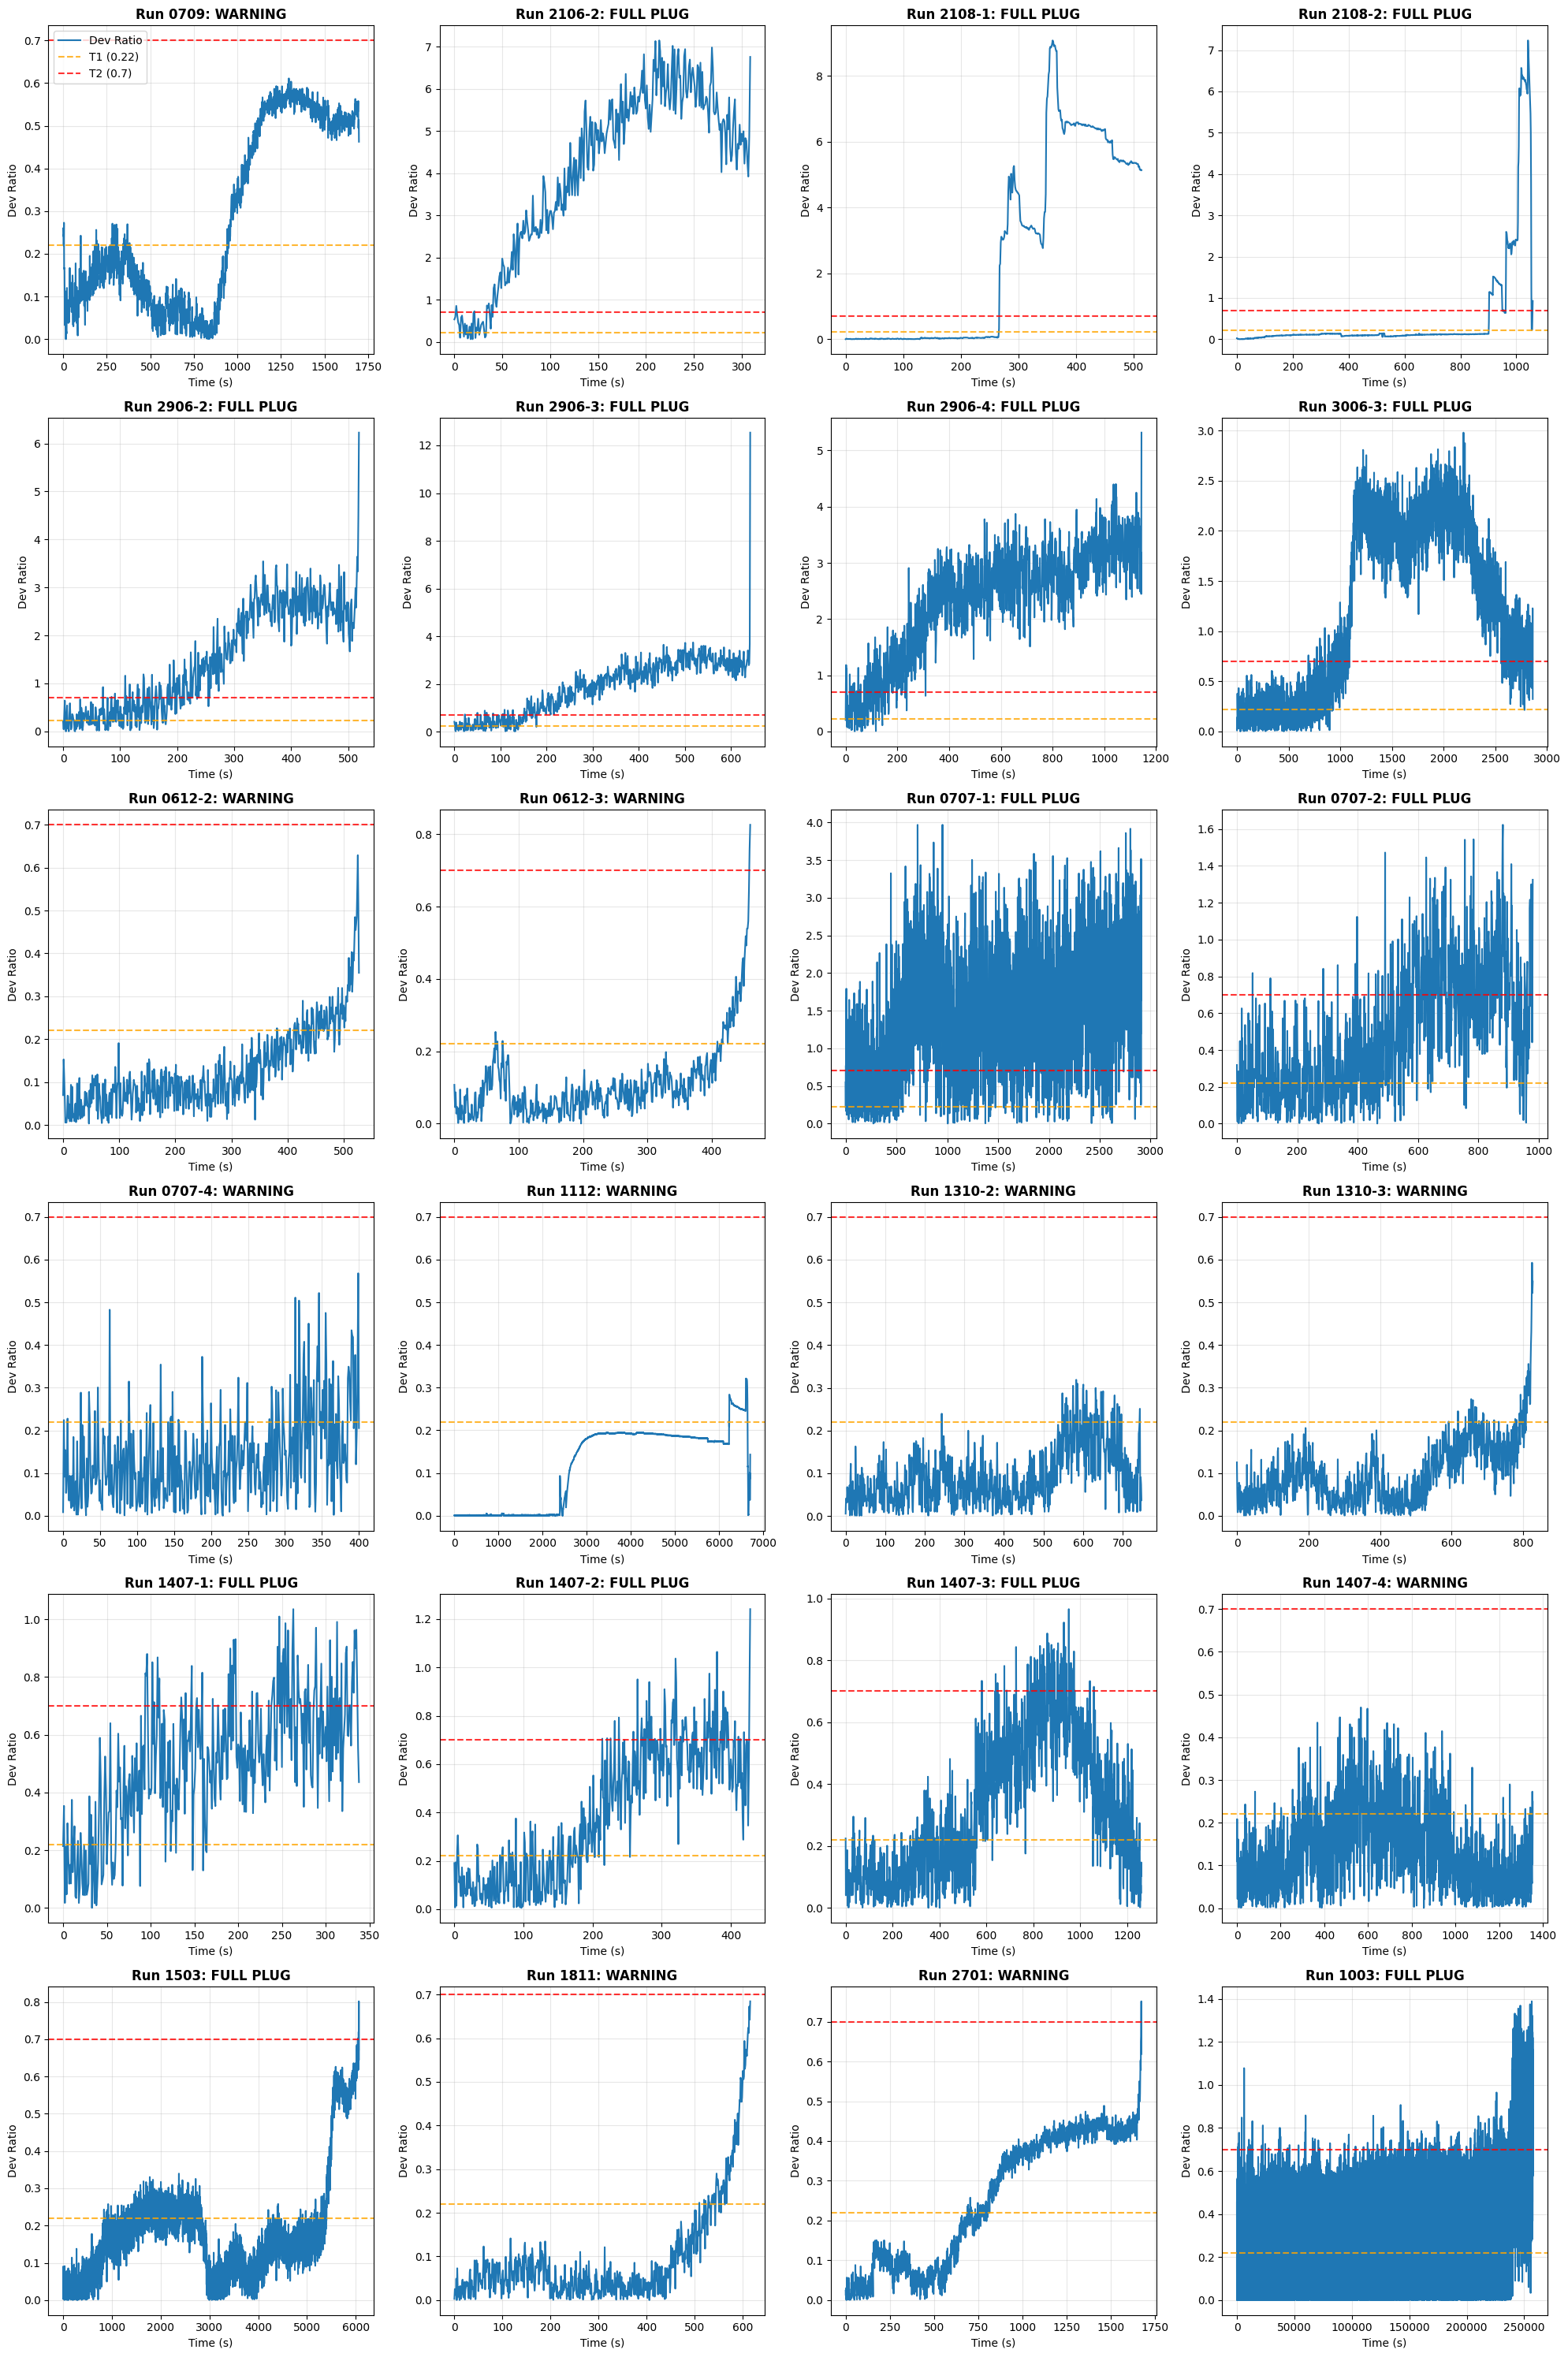

In [220]:
plot_plug_analysis(labeled_plug_dfs, 0.22, 0.70, plug_names)

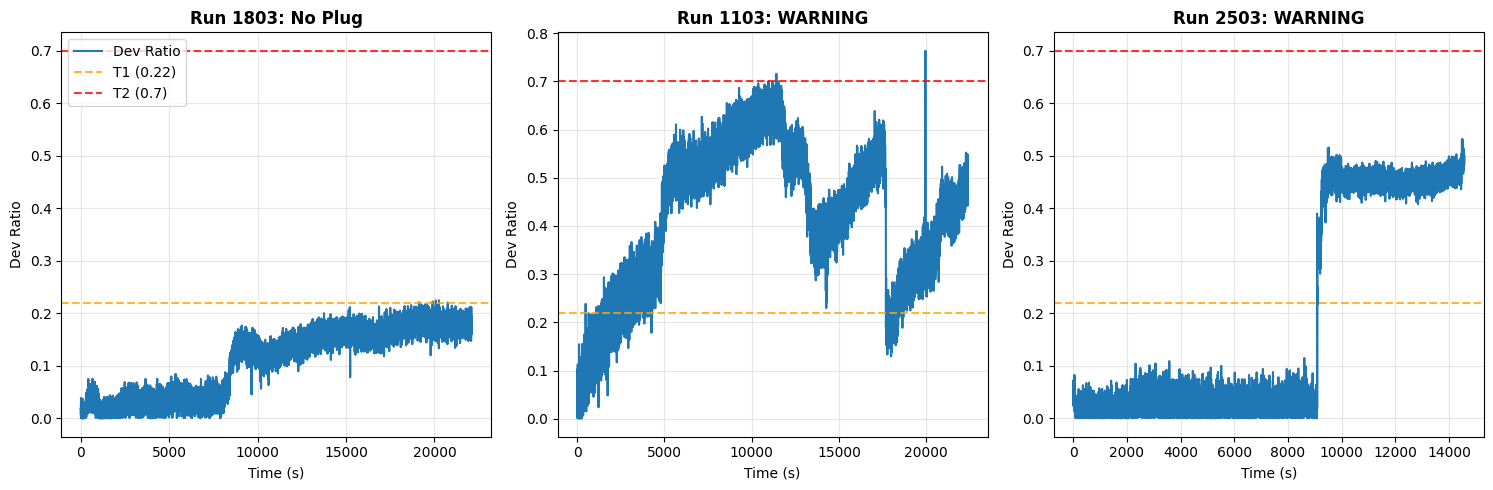

In [221]:
plot_plug_analysis(labeled_partial_plug_dfs, 0.22, 0.70, partial_plug_names)

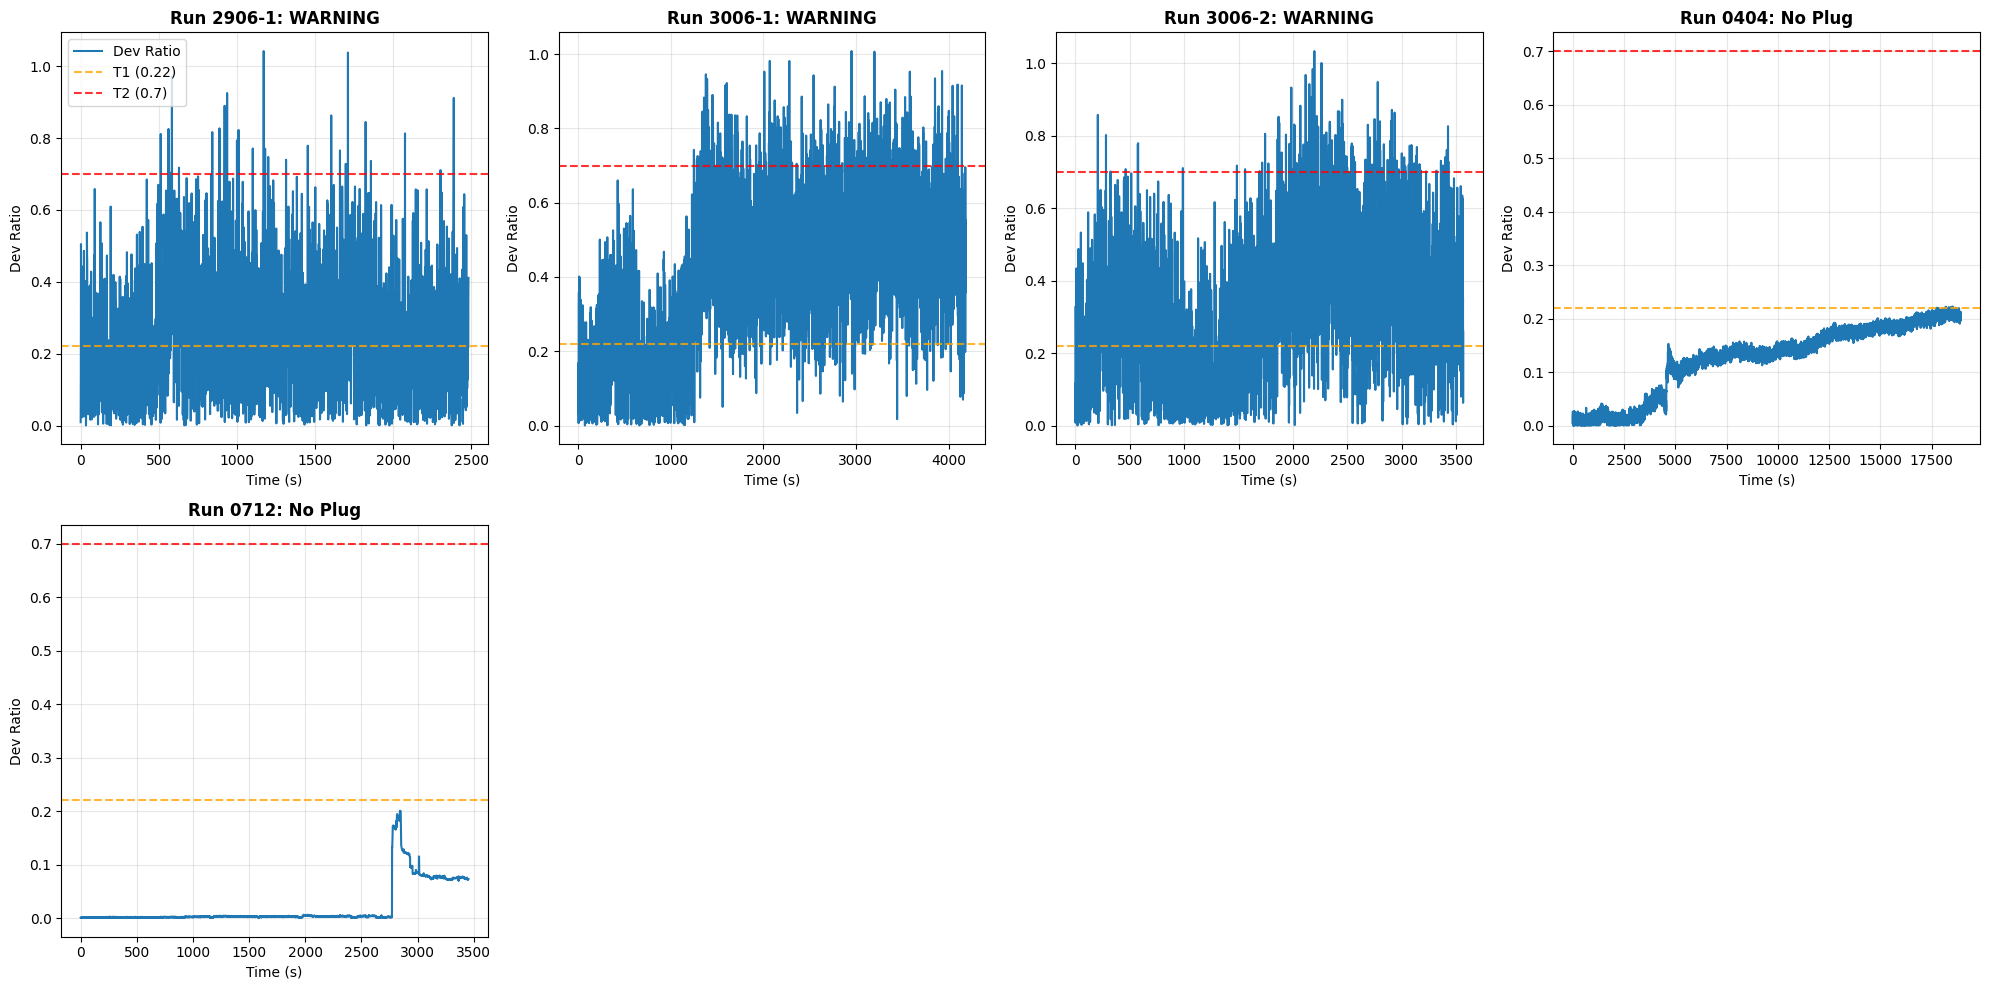

In [222]:
plot_plug_analysis(labeled_no_plug_dfs, 0.22, 0.70, no_plug_names)

## Finjusterer labels og lagrer runs

In [223]:
def apply_manual_plug_labels(dfs, tail_percent=0.15):
    corrected_dfs = []
    for df in dfs:
        temp_df = df.copy()

        if (temp_df['Plug_Label'] == 1).any() and not (temp_df['Plug_Label'] == 2).any():

            warning_indices = temp_df.index[temp_df['Plug_Label'] == 1].tolist()
            num_to_convert = int(len(warning_indices) * tail_percent)
            
            if num_to_convert > 0:
                plug_indices = warning_indices[-num_to_convert:]
                temp_df.loc[plug_indices, 'Plug_Label'] = 2
                
        corrected_dfs.append(temp_df)
    return corrected_dfs

corrected_labeled_plug_dfs = apply_manual_plug_labels(labeled_plug_dfs)

In [227]:
labeled_no_plug_dfs.append(reordered_no_plug_df)

In [228]:
for df in labeled_no_plug_dfs:
    df['Plug_Label'] = 0

In [229]:
for i, df in enumerate(labeled_plug_dfs):
    df.to_csv(f'../data/labeled/plug/{plug_names[i]}.csv', index=False)
for i, df in enumerate(labeled_no_plug_dfs):
    df.to_csv(f'../data/labeled/no_plug/{no_plug_names[i]}.csv', index=False)
for i, df in enumerate(labeled_partial_plug_dfs):
    df.to_csv(f'../data/labeled/partial_plug/{partial_plug_names[i]}.csv', index=False)